In [1]:
pip install sec-api openai python-dotenv


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



✂️ Analyzing 60 chunk(s)...

🔍 Analyzing chunk 1/60...
🔍 Analyzing chunk 2/60...
🔍 Analyzing chunk 3/60...
🔍 Analyzing chunk 4/60...
🔍 Analyzing chunk 5/60...
🔍 Analyzing chunk 6/60...
🔍 Analyzing chunk 7/60...
🔍 Analyzing chunk 8/60...
🔍 Analyzing chunk 9/60...
🔍 Analyzing chunk 10/60...
🔍 Analyzing chunk 11/60...
🔍 Analyzing chunk 12/60...
🔍 Analyzing chunk 13/60...
🔍 Analyzing chunk 14/60...
🔍 Analyzing chunk 15/60...
🔍 Analyzing chunk 16/60...
🔍 Analyzing chunk 17/60...
🔍 Analyzing chunk 18/60...
🔍 Analyzing chunk 19/60...
🔍 Analyzing chunk 20/60...
🔍 Analyzing chunk 21/60...
🔍 Analyzing chunk 22/60...
🔍 Analyzing chunk 23/60...
🔍 Analyzing chunk 24/60...
🔍 Analyzing chunk 25/60...
🔍 Analyzing chunk 26/60...
🔍 Analyzing chunk 27/60...
🔍 Analyzing chunk 28/60...
🔍 Analyzing chunk 29/60...
🔍 Analyzing chunk 30/60...
🔍 Analyzing chunk 31/60...
🔍 Analyzing chunk 32/60...
🔍 Analyzing chunk 33/60...
🔍 Analyzing chunk 34/60...
🔍 Analyzing chunk 35/60...
🔍 Analyzing chunk 36/60...
🔍 Analy

C:\Users\mason\AppData\Local\Temp\ipykernel_27108\335995789.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([gpt_scores, vader_scores], labels=["GPT-4o", "VADER"])


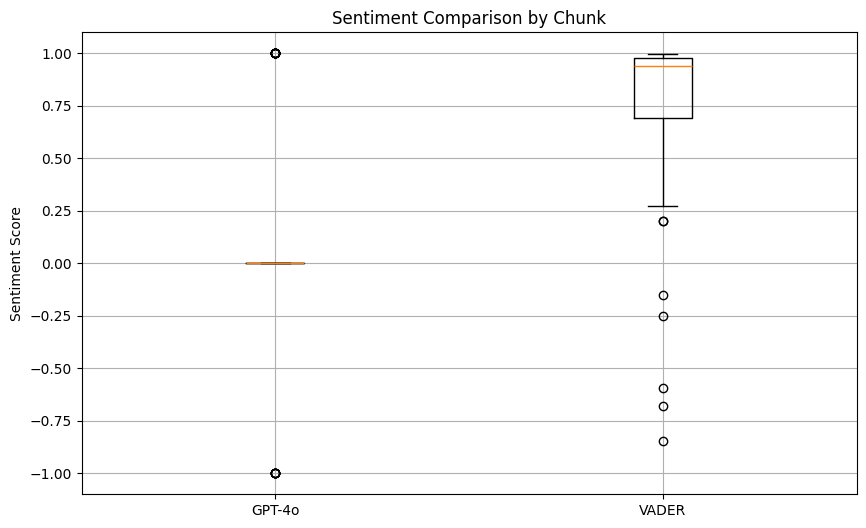

In [12]:
import os
from dotenv import load_dotenv
from sec_api import ExtractorApi
from openai import OpenAI
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import json


# Load API keys
load_dotenv()
SEC_API_KEY = os.getenv("SEC_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

# Initialize APIs
client = OpenAI(api_key=OPENAI_API_KEY)
extractor_api = ExtractorApi(SEC_API_KEY)

# Known working 10-K URL (Tesla 2020)
filing_url = "https://www.sec.gov/Archives/edgar/data/1318605/000156459021004599/tsla-10k_20201231.htm"

# Step 1: Extract MD&A section
def extract_mda(filing_url):
    try:
        print("📄 Extracting Item 7 (MD&A)...")
        return extractor_api.get_section(filing_url, "7", "text")
    except Exception as e:
        print("❌ Extraction error:", e)
        return ""

# Step 2: Chunk text
def chunk_text(text, max_tokens=2000):
    paragraphs = text.split("\n")
    chunks = []
    current_chunk = ""
    for para in paragraphs:
        if len(current_chunk) + len(para) < max_tokens:
            current_chunk += para + "\n"
        else:
            chunks.append(current_chunk.strip())
            current_chunk = para + "\n"
    if current_chunk:
        chunks.append(current_chunk.strip())
    return chunks

def analyze_sentiment_vader(text):
    vader = SentimentIntensityAnalyzer()
    score = vader.polarity_scores(text)
    return score['compound']  # Returns a value from -1 (neg) to +1 (pos)

import re

def extract_sentiment_label(gpt_response):
    match = re.search(r'"sentiment"\s*:\s*"(\w+)"', gpt_response.lower())
    if match:
        label = match.group(1)
        return {"positive": 1, "neutral": 0, "negative": -1}.get(label, 0)
    return 0  # default if not found

# Step 3: GPT-4o Sentiment Analysis
def analyze_sentiment_openai(text, model="gpt-4o"):
    prompt = f"""
You are a financial analyst. Read the following section from a 10-K filing and determine the overall sentiment (positive, neutral, or negative). Also, provide a short explanation for your reasoning.

Text:
\"\"\"
{text}
\"\"\"

Respond in the following JSON format:
{{
  "sentiment": "...",
  "explanation": "..."
}}
    """
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
    )
    return response.choices[0].message.content

# Step 4: Run full analysis
def run_sentiment_analysis(filing_url):
    item_7_text = extract_mda(filing_url)
    if not item_7_text:
        print("❌ No MD&A text extracted.")
        return

    chunks = chunk_text(item_7_text)
    results = []

    print(f"\n✂️ Analyzing {len(chunks)} chunk(s)...\n")
    for i, chunk in enumerate(chunks):
        print(f"🔍 Analyzing chunk {i+1}/{len(chunks)}...")
        result = analyze_sentiment_openai(chunk)
        results.append(result)

    print("\n📊 Final Sentiment Results:")
    for i, res in enumerate(results):
        print(f"\n🔹 Chunk {i+1} Result:\n{res}")

# 🔁 Run the full pipeline
gpt_results = []
vader_results = []

print(f"\n✂️ Analyzing {len(chunks)} chunk(s)...\n")
for i, chunk in enumerate(chunks):
    print(f"🔍 Analyzing chunk {i+1}/{len(chunks)}...")

    # GPT-4o sentiment
    gpt_raw = analyze_sentiment_openai(chunk)
    gpt_score = extract_sentiment_label(gpt_raw)
    gpt_results.append(gpt_score)

    # VADER sentiment
    vader_score = analyze_sentiment_vader(chunk)
    vader_results.append(vader_score)


# Show results
print("\n📊 GPT-4o Sentiment Scores:", gpt_results)
print("📊 VADER Sentiment Scores:", vader_results)

def plot_sentiment_distributions(gpt_scores, vader_scores):
    plt.figure(figsize=(10, 6))

    # Combine into box plots
    plt.boxplot([gpt_scores, vader_scores], labels=["GPT-4o", "VADER"])
    plt.title("Sentiment Comparison by Chunk")
    plt.ylabel("Sentiment Score")
    plt.grid(True)
    plt.show()



# Plot both
plot_sentiment_distributions(gpt_results, vader_results)


def plot_sentiment_distributions(gpt_scores, vader_scores):
    plt.figure(figsize=(10, 6))

    # Combine into box plots
    plt.boxplot([gpt_scores, vader_scores], labels=["GPT-4o", "VADER"])
    plt.title("Sentiment Comparison by Chunk")
    plt.ylabel("Sentiment Score")
    plt.grid(True)
    plt.show()



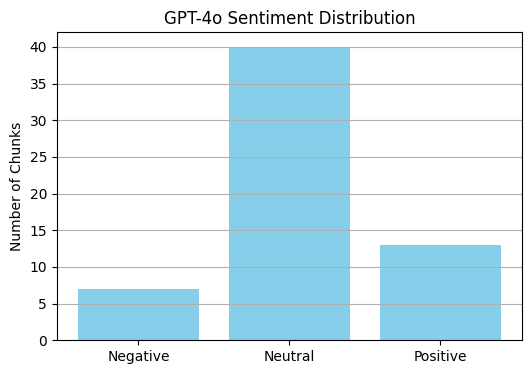

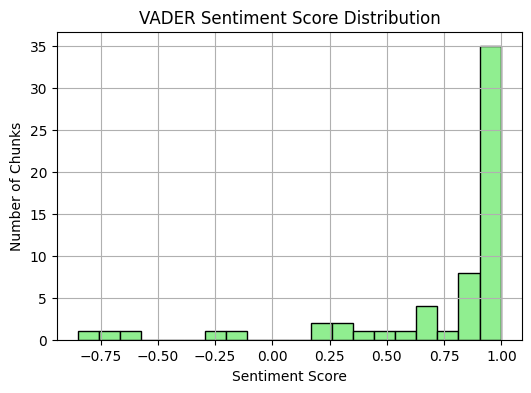

In [13]:
def plot_gpt_sentiment_distribution(gpt_scores):
    import matplotlib.pyplot as plt
    from collections import Counter

    counts = Counter(gpt_scores)
    labels = ['Negative', 'Neutral', 'Positive']
    values = [counts.get(-1, 0), counts.get(0, 0), counts.get(1, 0)]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, values, color='skyblue')
    plt.title("GPT-4o Sentiment Distribution")
    plt.ylabel("Number of Chunks")
    plt.grid(axis='y')
    plt.show()

def plot_vader_sentiment_distribution(vader_scores):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 4))
    plt.hist(vader_scores, bins=20, color='lightgreen', edgecolor='black')
    plt.title("VADER Sentiment Score Distribution")
    plt.xlabel("Sentiment Score")
    plt.ylabel("Number of Chunks")
    plt.grid(True)
    plt.show()

plot_gpt_sentiment_distribution(gpt_results)
plot_vader_sentiment_distribution(vader_results)
